In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Processing and Feature Engineering

The dataset contains 1,338 observations and 7 variables, and there are no missing values in any of the columns. Based on the summary statistics and visualizations, the distribution of medical charges is highly right-skewed, meaning most people have lower costs while a smaller group has very high expenses. The boxplot confirms this by showing many high-value outliers.

From the scatter plot, BMI shows a weak to moderate positive relationship with charges, but it is not a strong predictor on its own. The most noticeable pattern is with smoking status. Smokers have significantly higher medical charges compared to non-smokers, with a much higher median and wider spread. This suggests that smoking is one of the strongest predictors of cost.

To improve the dataset, a new feature called bmi_age was created by multiplying BMI and age to capture the combined effect of these variables on medical costs. Additionally, the smoker, sex, and region variables were converted into binary features to make it easier for modeling.

Finally, StandardScaler was applied to normalize numerical features so they are centered around zero and have a standard deviation of one. This is important because many machine learning models perform better when features are normalized and not dominated by large values. The scaler was fit only on the training data to avoid data leakage, and the same transformation was applied to the test set.

In [ ]:
data = pd.read_csv("insurance.csv")

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
print("Dataset Info:")
data.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
print(data.isnull())

        age    sex    bmi  children  smoker  region  charges
0     False  False  False     False   False   False    False
1     False  False  False     False   False   False    False
2     False  False  False     False   False   False    False
3     False  False  False     False   False   False    False
4     False  False  False     False   False   False    False
...     ...    ...    ...       ...     ...     ...      ...
1333  False  False  False     False   False   False    False
1334  False  False  False     False   False   False    False
1335  False  False  False     False   False   False    False
1336  False  False  False     False   False   False    False
1337  False  False  False     False   False   False    False

[1338 rows x 7 columns]


In [ ]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
print("Basic Statistics")
data.describe()

Basic Statistics


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

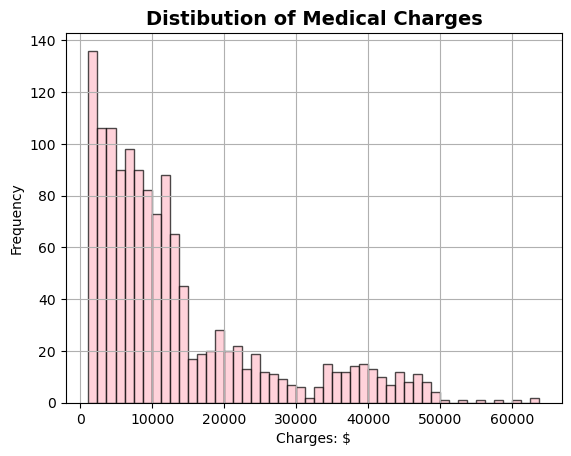

In [ ]:
data['charges'].hist(bins=50, color='pink', alpha=0.7, edgecolor='black')
plt.title("Distibution of Medical Charges", fontsize=14, fontweight='bold')
plt.xlabel("Charges: $")
plt.ylabel("Frequency")
plt.show()

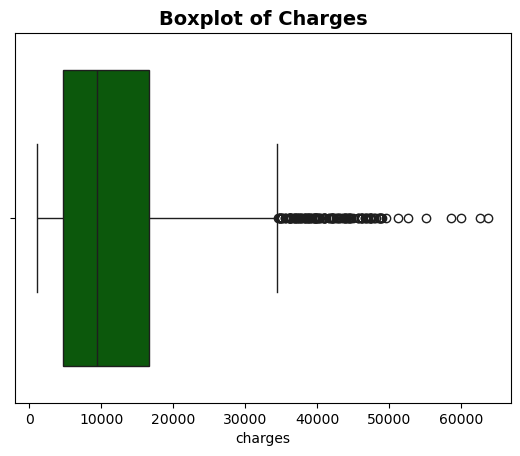

In [ ]:
sns.boxplot(x=data['charges'], color='darkgreen')
plt.title("Boxplot of Charges",fontsize=14, fontweight='bold')
plt.show()

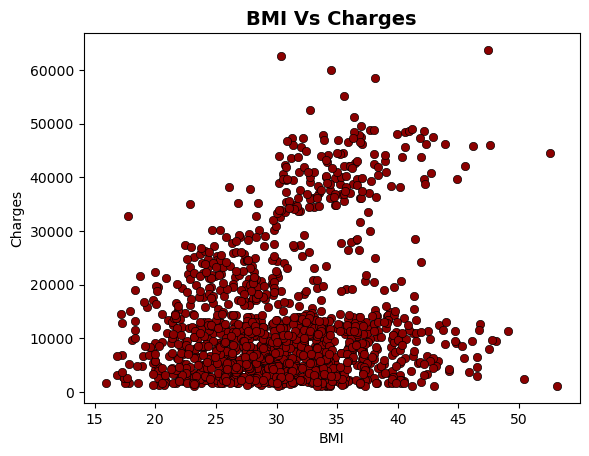

In [ ]:
sns.scatterplot(x='bmi',y='charges', data=data, color='darkred', edgecolor='black')
plt.title("BMI Vs Charges", fontsize=14, fontweight='bold')
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

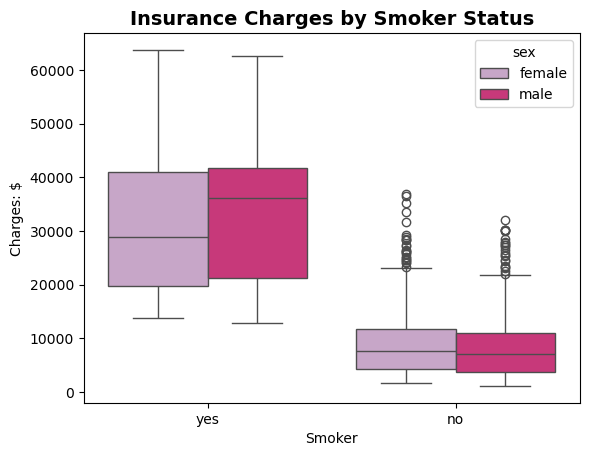

In [ ]:
sns.boxplot(data=data, x='smoker',y='charges', palette='PuRd', hue='sex')
plt.title("Insurance Charges by Smoker Status", fontsize=14, fontweight='bold')
plt.xlabel("Smoker")
plt.ylabel("Charges: $")
plt.show()

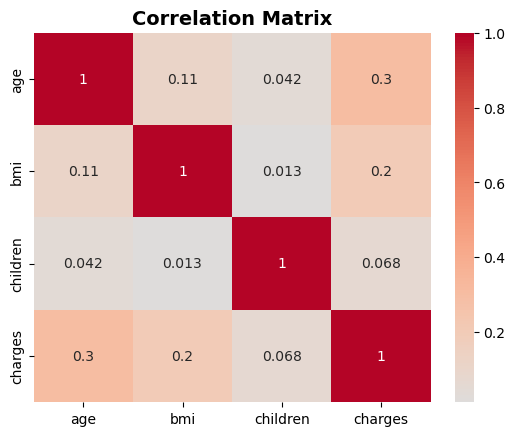

In [ ]:
#Correlation Analysis

sns.heatmap(data.corr(numeric_only=True),annot=True, cmap="coolwarm",center=0)
plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()

In [ ]:
#New Feature

data["bmi_age"] = data["bmi"] * data["age"]

In [ ]:
#Separate features (X) and target (y)

X = data.drop('charges', axis=1)
y = data['charges']

print("\nFeatures:\n", X.head())
print("\nPrediction:\n", y.head())


Features:
    age     sex     bmi  children smoker     region  bmi_age
0   19  female  27.900         0    yes  southwest  530.100
1   18    male  33.770         1     no  southeast  607.860
2   28    male  33.000         3     no  southeast  924.000
3   33    male  22.705         0     no  northwest  749.265
4   32    male  28.880         0     no  northwest  924.160

Prediction:
 0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [ ]:
#Converting categorical columns into multiple binary columns

print("Encoding catgorical variables: sex, region, smoker")
X_encoding = pd.get_dummies(X, drop_first=False)#all categories will be kept for clarity
X_encoding = X_encoding.astype(int) #integer conversion

print("\nEncoded Features:\n", X_encoding.head())
print("\nFeature names after encoding:\n", X_encoding.columns.tolist())


Encoding catgorical variables: sex, region, smoker

Encoded Features:
    age  bmi  children  bmi_age  sex_female  sex_male  smoker_no  smoker_yes  \
0   19   27         0      530           1         0          0           1   
1   18   33         1      607           0         1          1           0   
2   28   33         3      924           0         1          1           0   
3   33   22         0      749           0         1          1           0   
4   32   28         0      924           0         1          1           0   

   region_northeast  region_northwest  region_southeast  region_southwest  
0                 0                 0                 0                 1  
1                 0                 0                 1                 0  
2                 0                 0                 1                 0  
3                 0                 1                 0                 0  
4                 0                 1                 0                 0 

Train/Test Split = This will be done before scaling to prevent data leakage. Also, the dataset has been split into 85% training and 15% testing to ensure the model has sufficient data to learn patterns while still reserving a portion of unseen data for reliable performance evaluation.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
print("Splitting data into training (85%) and testing(15%)")
X_train, X_test, y_train, y_test = train_test_split(X_encoding, y, test_size=0.15, random_state=42)

Splitting data into training (85%) and testing(15%)


In [ ]:
print(f"Training set - Mean: ${y_train.mean():.2f}, Std: ${y_train.std():.2f}")
print(f"Testing set - Mean: ${y_test.mean():.2f}, Std: ${y_test.std():.2f}")

Training set - Mean: $13285.25, Std: $12068.86
Testing set - Mean: $13186.57, Std: $12370.49


In [ ]:
#Apply StandardScaler
#Apply fit scaler on training data only, the apply transform both train and test.
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print("Training and test data have been standarized.")

Training and test data have been standarized.


In [ ]:
X_train_scaled.head()

,age,bmi,children,bmi_age,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,0.906079,-0.498283,-0.901419,0.408054,-0.978249,0.978249,-1.975060,1.975060,-0.563469,1.766229,-0.610891,-0.568887
1,-0.657217,2.269337,0.745028,0.224890,-0.978249,0.978249,0.506314,-0.506314,-0.563469,-0.566178,1.636952,-0.568887
2,-1.438865,-0.498283,0.745028,-1.316738,-0.978249,0.978249,0.506314,-0.506314,-0.563469,1.766229,-0.610891,-0.568887
3,-1.367806,-0.661085,-0.078195,-1.282395,1.022235,-1.022235,-1.975060,1.975060,-0.563469,-0.566178,1.636952,-0.568887
4,-0.870394,-0.986687,-0.901419,-1.030545,1.022235,-1.022235,-1.975060,1.975060,-0.563469,-0.566178,1.636952,-0.568887


In [ ]:
X_test_scaled.head()

,age,bmi,children,bmi_age,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,0.408667,-0.823886,0.745028,-0.145253,1.022235,-1.022235,0.506314,-0.506314,1.774721,-0.566178,-0.610891,-0.568887
1,-0.230863,-0.009880,-0.901419,-0.244467,1.022235,-1.022235,0.506314,-0.506314,-0.563469,1.766229,-0.610891,-0.568887
2,1.758787,-0.661085,-0.901419,0.976625,1.022235,-1.022235,-1.975060,1.975060,-0.563469,1.766229,-0.610891,-0.568887
3,0.479726,-0.823886,1.568251,-0.046039,-0.978249,0.978249,0.506314,-0.506314,-0.563469,1.766229,-0.610891,-0.568887
4,-1.438865,0.152921,-0.901419,-1.148838,-0.978249,0.978249,-1.975060,1.975060,-0.563469,1.766229,-0.610891,-0.568887


Modeling and Evaluation

Baseline linear regression is the simplest approach. It tries to find the best line (or equation) that minimizes the difference between predicted and actual values. In other words, it focuses only on fitting the training data as closely as possible. The issue with this is that it can sometimes overfit, meaning it learns the data too well, including noise, and does not perform as well on new data.

Ridge regression improves on this by adding a penalty term based on the squared magnitude of the coefficients (L2 regularization). As explained by An Introduction to Statistical Learning, ridge regression still seeks to fit the data well, but it also includes a shrinkage penalty that pulls coefficients toward zero (James et al., 2023, p. 240). This helps reduce model complexity and variance. Its advantage over least squares is tied to the bias-variance trade-off, where a small increase in bias leads to a reduction in variance and more stable predictions (James et al., 2023, p. 242). However, ridge regression does not remove variables; it keeps all predictors, which can make interpretation more difficult when many features are included.

Lasso regression works in a similar way but uses an L1 penalty instead. This penalty can force some coefficients to become exactly zero, effectively removing less important variables from the model (James et al., 2023, p. 244). Because of this, lasso produces simpler and more interpretable models compared to ridge regression, since it keeps only the most relevant predictors.

In general, lasso tends to perform better when only a small number of predictors have a strong effect, while ridge performs better when many predictors contribute to the outcome (James et al., 2023, p. 248). Overall, both ridge and lasso address a key weakness of baseline linear regression by managing the bias-variance trade-off. They introduce a small amount of bias but significantly reduce variance, which often leads to better performance on new, unseen data.

Reference

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). An introduction to statistical learning: With applications in Python. Springer.

In [ ]:
#Regression Models for training
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# Create Linear Regression Model
lr = LinearRegression()
# Train model
lr.fit(X_train_scaled, y_train)
# Make predictions
y_pred_lr = lr.predict(X_test_scaled)

# Create Ridge Regression Model
ridge = Ridge(alpha=1.0)
# Train model
ridge.fit(X_train_scaled, y_train)
# Make predictions
y_pred_ridge = ridge.predict(X_test_scaled)

# Create Lasso Regression Model
lasso = Lasso(alpha=0.1)
# Train model
lasso.fit(X_train_scaled, y_train)
# Make predictions
y_pred_lasso = lasso.predict(X_test_scaled)

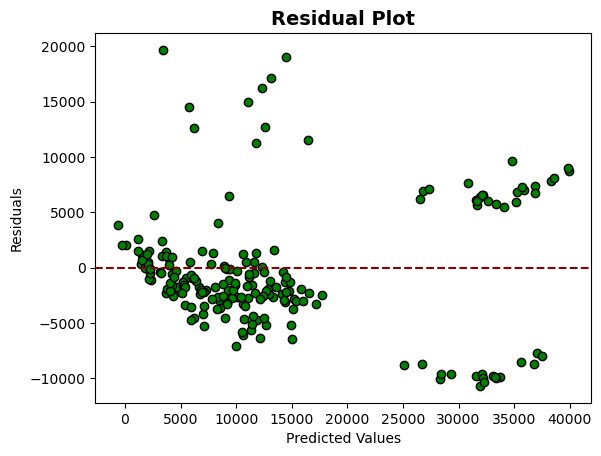

In [ ]:
residuals = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals, color='green', edgecolor='black')
plt.axhline(y=0, color='darkred', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot",fontsize=14, fontweight='bold')
plt.show()

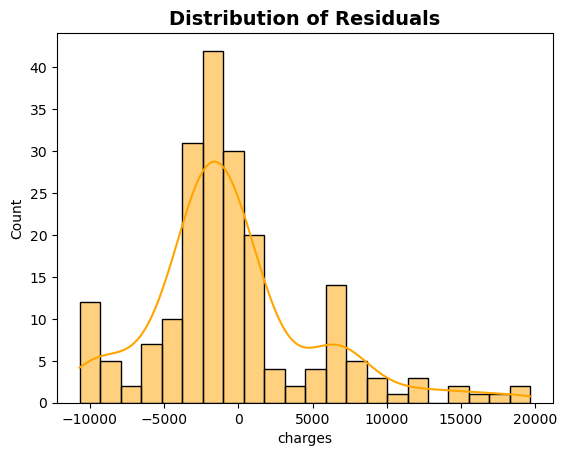

In [ ]:
sns.histplot(residuals, color='orange', kde=True)
plt.title("Distribution of Residuals",fontsize=14, fontweight='bold')
plt.show()

After checking the residual plots, a few concerns about the model fit were identified. In the residual plot, the points are not completely random around zero. Instead, the spread of the residuals increases as the predicted values increase. This suggests that the model is less accurate for higher medical charges, which is a sign of unequal error spread (heteroscedasticity). There are also some clear clusters and outliers, especially at higher predicted values, which means the model is not capturing those cases as well.

The histogram of residuals shows that the distribution is not perfectly symmetric and is slightly skewed. This means the errors are not fully normally distributed, which is one of the assumptions of linear regression. This is likely happening because the original charges variable is also skewed and contains some extreme values.

These results suggest that the baseline linear regression model is somewhat limited and may be too simple for this dataset. Ridge and Lasso regression were used to help improve model stability and reduce the impact of extreme values.

While the model works reasonably well, these checks show that it does not perfectly meet all assumptions, especially for higher-cost cases.

In [ ]:
#Evaluate model performance with RMSE, MAE and R-squared

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n---Linear Regression---")
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE: ", mean_absolute_error(y_test, y_pred_lr))
print("R-squared: ", r2_score(y_test, y_pred_lr))

print("\n---Ridge Regression---")
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("MAE: ", mean_absolute_error(y_test, y_pred_ridge))
print("R-squared: ", r2_score(y_test, y_pred_ridge))

print("\n---Lasso Regression---")
print("RMSE: ", np.sqrt(mean_squared_error(y_test,y_pred_lasso)))
print("MAE: ", mean_absolute_error(y_test, y_pred_lasso))
print("R-squared: ", r2_score(y_test, y_pred_lasso))


---Linear Regression---
RMSE:  5559.193798576803
MAE:  4043.842813260435
R-squared:  0.7970375229651278

---Ridge Regression---
RMSE:  5556.504008866816
MAE:  4041.5882454311195
R-squared:  0.7972338803255884

---Lasso Regression---
RMSE:  5559.073132208264
MAE:  4043.721644463779
R-squared:  0.7970463337676096


Model Performance Evaluation

Model performance was evaluated using RMSE, MAE, and R-squared to understand how well each model predicts medical charges. RMSE was chosen because it gives more weight to larger errors, which is important since some medical charges are very high and we want to avoid big mistakes. MAE was included because it shows the average difference between predicted and actual values in a more straightforward way. R-squared was used to show how much of the variation in medical charges is explained by the model.

The results show that all three models perform very similarly, with only small differences between them. Ridge regression performed slightly better than the baseline linear regression, with a lower RMSE and MAE and a slightly higher R-squared value. This suggests that adding regularization helped the model make more stable predictions. Lasso regression performed almost the same as the baseline model, meaning removing some variables did not significantly change performance in this case.

The differences between the models are small, which suggests that the data already has a strong linear relationship. However, Ridge regression appears to be the best option because it slightly improves accuracy while also making the model more stable.

In [ ]:
#Compare Model Performance

results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "RMSE": [5559.19, 5556.50, 5559.07],
    "MAE": [4043.84, 4041.59, 4043.72],
    "R2": [0.7970, 0.7972, 0.7970]
    
})
print(results)

    Model     RMSE      MAE      R2
0  Linear  5559.19  4043.84  0.7970
1   Ridge  5556.50  4041.59  0.7972
2   Lasso  5559.07  4043.72  0.7970


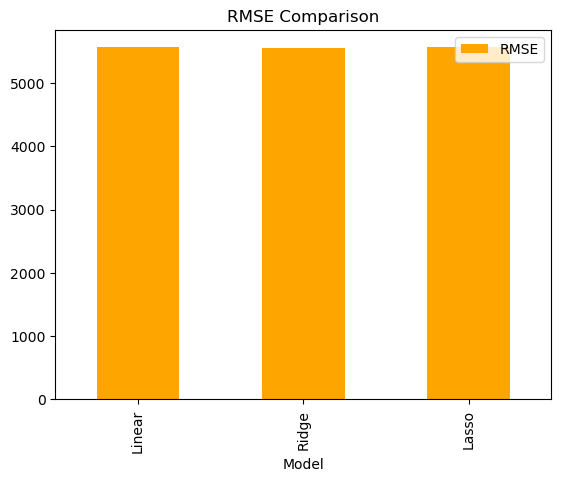

In [ ]:
results.plot(x="Model", y="RMSE", kind="bar", color="orange")
plt.title("RMSE Comparison")
plt.show()

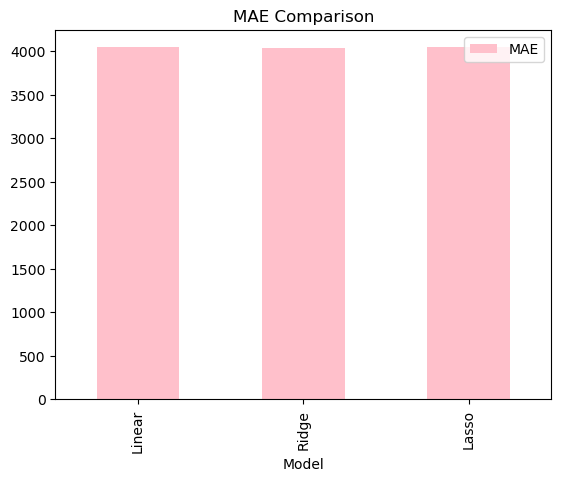

In [ ]:
results.plot(x="Model", y="MAE", kind="bar", color="pink")
plt.title("MAE Comparison")
plt.show()

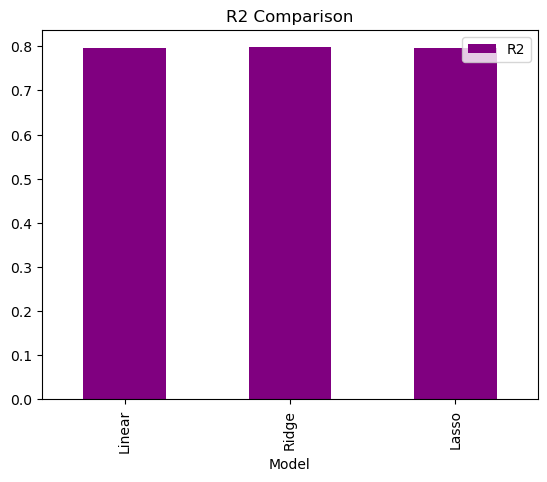

In [ ]:
results.plot(x="Model", y="R2", kind="bar", color="purple")
plt.title("R2 Comparison")
plt.show()

In [ ]:
#Assess feature importance for best-performing model: Ridge Regression!

ridge_coefficients = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": ridge.coef_
})

ridge_coefficients["Abs_Coefficient"] = ridge_coefficients["Coefficient"].abs()
ridge_coefficients = ridge_coefficients.sort_values(by="Abs_Coefficient", ascending=False)

print(ridge_coefficients)

             Feature  Coefficient  Abs_Coefficient
6          smoker_no -4790.029978      4790.029978
7         smoker_yes  4790.029978      4790.029978
0                age  3899.341665      3899.341665
1                bmi  2124.043357      2124.043357
2           children   516.750360       516.750360
3            bmi_age  -292.003157       292.003157
8   region_northeast   175.976687       175.976687
11  region_southwest  -108.091772       108.091772
10  region_southeast   -97.995461        97.995461
9   region_northwest    34.497216        34.497216
5           sex_male   -31.355434        31.355434
4         sex_female    31.355434        31.355434


Feature Importance Conclusions

Feature importance was determined using the coefficients from the Ridge model. The features with the largest absolute coefficients were smoking status, age, BMI, and bmi_age, which means they had the biggest impact on predicting medical charges. Smoking status was the most important factor, followed by age and BMI.

This makes sense because smoking increases health risks and leads to higher medical costs. Age is also important since older patients typically require more healthcare. BMI and the bmi_age feature show that body weight and its interaction with age also affect medical expenses.

Overall, the results are logical and match real-world expectations. The most important features help explain why some patients have higher predicted costs than others.

Final Recommendations

Healthcare providers can use these predictions to identify patients who are more likely to have high medical costs. Since smoking, age, and BMI were the most important factors, providers can focus on prevention strategies like smoking cessation programs, weight management, and early monitoring for higher-risk patients. Age is also important since older patients usually need more care. Overall, the important features match what we would expect in real life.

This can help reduce long-term costs by addressing issues earlier. However, the model is not perfect, especially for very high-cost patients, so it should be used as a support tool rather than a final decision-maker. Overall, it can help providers allocate resources better and improve patient care.